In [1]:
import sys, os
import numpy as np
import glob
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import h5py
from netCDF4 import Dataset
from scipy.interpolate import griddata
from pathlib import Path
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import LinearSegmentedColormap

# sys.path.insert(0, r"B:\publication_1")
import Read_RTM as ReadEC
import Find_Overpass_Info as Find_Overpass_Info

# from Make_RTM import Calc3DBufferSize

In [2]:
def get_baseline(folder, Product):
    files = sorted(Path(folder).glob("*" + Product + "*"))
    if not files:
        print(f"No {Product} file found in {folder}")
        return "unknown"
    filename = files[0].name
    if "ECA_EX" not in filename:
        print(f"Cannot extract baseline from {filename}")
        return "unknown"
    return filename.split("ECA_EX", 1)[1][:2]







def Calc3DBufferSize(ACM3D, ia, iacr, BMAFLX, which_buffer):
    WANT_PRINTS = False
    # BG: Decide to use my buffer, not dynamic buffer!
    if which_buffer == 0:   along_dim, across_dim =  0,  0 # ( 1, 1) comp-domain  MCIPA 
    elif which_buffer == 1: along_dim, across_dim =  2,  2 # ( 5, 5) comp-domain  Test Buffer
    elif which_buffer == 2: along_dim, across_dim = 10, 10 # (21,21) comp-domain  ~BBR +  5 pixels-buffer
    elif which_buffer == 3: along_dim, across_dim = 20, 20 # (41,41) comp-domain  ~BBR + 35 pixels-buffer
        # NEW:
    elif which_buffer == 4:  # Sun-depenent buffer
        LOWER_THRESHOLD_along_dim  = 10
        LOWER_THRESHOLD_across_dim = 10
        UPPER_THRESHOLD_across_dim = 30

        cloud_hight_estimate = 12 # Upper bound clouds (in Northern Latitudes)

        p0 = (ACM3D.longitude[iacr,  ia-5],  ACM3D.latitude[iacr,  ia-5])
        p1 = (ACM3D.longitude[iacr,  ia+5],  ACM3D.latitude[iacr,  ia+5])
        px = (p0[0], p1[1])

        p0_km = pdeg2km(p0)
        p1_km = pdeg2km(p1)
        px_km = pdeg2km(px)

        # Calculate distances between points in kilometers
        # Using formula: distance = sqrt((x2 - x1)^2 + (y2 - y1)^2)
        p0p1 = np.sqrt(np.power(p1_km[0] - p0_km[0], 2) + np.power(p1_km[1] - p0_km[1], 2))
        p0px = np.sqrt(np.power(px_km[0] - p0_km[0], 2) + np.power(px_km[1] - p0_km[1], 2))

        # Calculate angle between satellite track and meridian line
        track_angle = np.rad2deg(np.arccos(p0px / p0p1))
            # This will always result in positive angles (km > 0)


        # Check if the satellite track is descending (going south) 
        # -> need to swith track_angle accordingly
        if p1_km[1] < p0_km[1]:       # Track goes south(west)
            track_angle = 180 + track_angle
        else:                         # Track goes north(west)
            track_angle = 360 - track_angle
        if WANT_PRINTS: print(f"Track angle = {track_angle:.0f}°")
        



                    ########### OLD ######################################
                        # # Satelite trajectory ANGLE
                        # dlon = p1[0] - p0[0]
                        # dlat = p1[1] - p0[1]
                        # angle = np.degrees(np.arctan2(dlon, dlat)) % 360
                        # if WANT_PRINTS: print(f"Satellite Trajectory Angle = {angle:.0f}°")

        latitude_wanted = ACMCOM.latitude_active[ia]
        longitude_wanted = ACMCOM.longitude_active[ia]
        dist = np.sqrt((BMAFLX.latitude - latitude_wanted)**2 + (BMAFLX.longitude - longitude_wanted)**2)
        indlatBMAFLX = np.unravel_index(np.argmin(dist, axis=None), dist.shape)
        sza  = BMAFLX.solar_zenith_angle[indlatBMAFLX,1].squeeze()  # Nadir view is in element one
        phi0 = BMAFLX.solar_azimuth_angle[indlatBMAFLX,1].squeeze()  # Nadir view is in element one

                    ################# OLD #################################
                        # phi_diff = (phi0 - angle) % 360 # % 360 means the difference is wrapped within [0, 360) degrees
                        # if WANT_PRINTS: print(f"sza = {sza:.0f} phi0 = {phi0:.0f}   -> phi_diff = {phi_diff:.0f}")


        # Angle between solar azimuth and satellite track
        phi_diff = (phi0 - track_angle) % 360

        factor_across = abs(np.sin(np.deg2rad(phi_diff)))
        factor_along  = abs(np.cos(np.deg2rad(phi_diff)))
        if WANT_PRINTS: print(f"factor_across = {factor_across:.2f}    factor_along = {factor_along:.2f}")
        
        factor_projected_length = abs(cloud_hight_estimate * np.tan(np.deg2rad(sza)))
        if WANT_PRINTS: print(f"factor_projected_length = {factor_projected_length:.2f}")

        along_dim  = int(factor_along * factor_projected_length)
        across_dim = int(factor_across * factor_projected_length)

        along_dim  = max(along_dim, LOWER_THRESHOLD_along_dim)
        across_dim = max(across_dim, LOWER_THRESHOLD_across_dim)

        # Not get across-track dim outside ECA frame (which end at pixel 0 and 190)
        max_across_index = 190 
        across_dim = min(across_dim, max_across_index - iacr, UPPER_THRESHOLD_across_dim)
        if WANT_PRINTS: print(f"along_dim = {along_dim} across_dim = {across_dim}")
        if WANT_PRINTS: print("\n\n")
    

    ialongs = np.arange(ia-along_dim, ia+along_dim+1)
    iacrosses = np.arange(iacr-across_dim, iacr+across_dim+1)
    
    Nx = iacrosses.shape[0]
    Ny = ialongs.shape[0]


    return Nx, Ny, iacrosses, ialongs




def get_solar_geometry(ial):
    latitude_wanted     = ACMCOM.latitude_active[ial]
    longitude_wanted    = ACMCOM.longitude_active[ial]
    dist                = np.sqrt((BMAFLX.latitude - latitude_wanted)**2 + (BMAFLX.longitude - longitude_wanted)**2)
    indlatBMAFLX        = np.unravel_index(np.argmin(dist, axis=None), dist.shape)
    sza_deg   = BMAFLX.solar_zenith_angle[indlatBMAFLX,1].squeeze()  # Nadir view is in element one
    phi0_deg  = BMAFLX.solar_azimuth_angle[indlatBMAFLX,1].squeeze()  # Nadir view is in element one
    # phi0_deg  = BMAFLX.viewing_azimuth_angle[indlatBMAFLX,1].squeeze()
    return sza_deg, phi0_deg






def pdeg2km(p):
    latfact = 111.32
    p0 = latfact*p[0]/1000
    lonfact = 40075 * np.cos(np.deg2rad( p[1] )) / 360
    p1 = latfact*p[1]/1000
    return (p0,p1)

def get_phi0_shift(ACMB3D, iacrosses, ialongs):
    # 1. Calculate solar azimuth track shift BEFORE reversing array indices
    p0 = (ACMB3D.longitude[iacrosses[0],  ialongs[0]],   ACMB3D.latitude[iacrosses[0],  ialongs[0]])
    p1 = (ACMB3D.longitude[iacrosses[0],  ialongs[-1]],  ACMB3D.latitude[iacrosses[0],  ialongs[-1]])
    px = (p0[0], p1[1])

    p0_km = pdeg2km(p0)
    p1_km = pdeg2km(p1)
    px_km = pdeg2km(px)

    # Calculate distances between points in kilometers
    # Using formula: distance = sqrt((x2 - x1)^2 + (y2 - y1)^2)
    p0p1 = np.sqrt(np.power(p1_km[0] - p0_km[0], 2) + np.power(p1_km[1] - p0_km[1], 2))
    p0px = np.sqrt(np.power(px_km[0] - p0_km[0], 2) + np.power(px_km[1] - p0_km[1], 2))

    # Calculate angle between satellite track and meridian line
    phi0_shift = np.rad2deg(np.arccos(p0px / p0p1))

    # Test if acending or decending frame
    if p1_km[1] < p0_km[1]:       # Track goes south
        phi0_shift = 180 - phi0_shift

    return phi0_shift

In [83]:


pathL2TestProducts_base = Path("A:\\projects\\NEVAR\\data\\CalVal\\SurfaceOverpasses")              # Path("/xnilu_wrk2/projects/NEVAR/data/CalVal/SurfaceOverpasses")
ProductPathRTM          = Path(r"B:\publication_1\RESULTS")
# ProductPathRTM          = Path(r"B:\publication_1\RESULTS_TEST")
  
librad_type         = 'SWIA'
version_identifier  = 'v01'
source_str          = 'solar'
baseline            = []
products_baseline   = []
want_product2       = False
sites = [
      # (Station,       lat,    lon) 
        ("Oslo",        59.942,	10.720),
        ("Karasjok",    69.464,	25.502),
        ("Gratangen",   68.732,	17.241), 
        ("Beitostølen", 61.251,	8.923),
        ("Værnes",      63.460,	10.931), 
        ("Østerås",     59.948,	10.603), 
        ("Trondheim",   63.415,	10.407), 
        ("Tromsø",      69.654,	18.937), 
        ("Bergen",      60.383,	5.333),  
        ("Hopen",       76.510,	25.013), 
        ("Brusdalen",   62.485,	6.480),  
        ("Jan-Mayen",   70.939,	-8.669), 
        ("Flesland",    60.289,	5.227),  
        ("Iskoras",     69.300,	25.346), 
        ("Rena",        61.376,	11.499), 
        ("Korgåsen",    69.936,	28.377), 
        ("Bjørnøya",    74.504,	18.998), 
        ("Filefjell",   61.178,	8.113),  
        ("Juvvasshøe",  61.678,	8.369),  
    ]





WANT_3D  = True      # MYSTIC or DISORT
WANT_EUP = False       # True -> eup -> TOA    False -> edir+edn -> SUR



idx_orbit = 3

overpasses = [
    ("Oslo", "02468D"), # Good
    ("Oslo", "04164D"), # Good 
    ("Oslo", "04164D"), # Good  

    ("Iskoras", "00912C"), # 3 (too high RTM)   -> would work, but much cloud
    ("Iskoras", "05673C"), # 4 (too high RTM)   -> can work,   but very cloudy
    ("Iskoras", "05004C"), # 5 (too low RTM)    -> VERY STRANGE LOWER ICE CLOUD (below surface) -> obs:453.0  RTM:33

    ("Bjørnøya", "06685C"), # 6 (too low RTM)   -> can work if not clouds outside buffer
    ("Bjørnøya", "11353C"), # 7 (too low RTM)   -> wont work,  low cloud put wrong by SCA assume (or wrong time)

    ("Filefjell", "00928D"), # 8 (too low RTM)  -> very interesting case, broken clouds, think make sense               ->     if use new phi code -> works good!

    ("Korgåsen", "06482C"), # 9 (too low RTM)   -> iacr=188 -> SCA stops at 190!
]
station, OrbitID = overpasses[idx_orbit]


# Distinguish minor modifications to .nc files
additional_spesifications = '' 
# additional_spesifications = '_AllLevels_TEST_5x5'









if WANT_EUP:    additional_spesifications += '_TOA'     
else:           additional_spesifications += '_SUR'        
# Pick the correct model version
librad_version = 'montecarlo_3D' if WANT_3D else 'disort_1D'
if want_product2: 'disort_1D' if WANT_3D else 'montecarlo_3D'


pathL2TestProducts = pathL2TestProducts_base / station
print("Directory exists:", pathL2TestProducts.exists())









"""######################### TESTING ###################################"""
TESTING = False
if TESTING:
    SceneName = "Orbit_07883D"
    Station, OrbitID = "_", "07883D"    

    # # Testing Acending Frame
    # SceneName = "Orbit_06600C"
    # Station, OrbitID = "_", "06600C"  

    # ProductPathRTM      = Path("B:\\RTM\\RESULTS") 
    # pathL2TestProducts_base = Path("A:\\projects\\NEVAR\\data\\EarthCARE_Real\\Orbit_07883D\\output") 

    
    ProductPathRTM      = Path("B:\\publication_1\\RESULTS_TEST") 
    pathL2TestProducts =  Path("A:\\projects\\NEVAR\\data\\EarthCARE_Real")  
    RTMdata             = Path("A:\\projects\\NEVAR\\data\\libRadtran\\data") #RTM input data 
"""#######################################################################"""







Product ='ALL_3D'
ProductPath = '*'+Product+'*'+OrbitID+'*'
ProductFile = os.path.join(pathL2TestProducts, ProductPath, '*'+Product+'*.h5')

if TESTING:
    ProductPath = '*'+Product+'*'
    ProductFile = os.path.join(pathL2TestProducts, SceneName, 'output', ProductPath, '*'+Product+'*.h5') 

    output_path = pathL2TestProducts / SceneName / "output" / ProductPath 
    print(sorted(output_path.rglob(f"*{Product}*.h5")))
    # print(ProductFile)
try: 
    ProductFile = sorted(glob.glob(ProductFile))[0]
    ACMB3D = ReadEC.Scene(Name=OrbitID)
    ACMB3D.ReadEarthCAREh5(ProductFile)
    ACMB3D.SetExtent()
    baseline.append(get_baseline(pathL2TestProducts, Product))
    products_baseline.append(Product)
except IndexError: 
    print(f"\n     Skipping {Product} {OrbitID}") 



Product ='BMA_FLX'
ProductPath = '*'+Product+'*'+OrbitID+'*'
ProductFile = os.path.join(pathL2TestProducts, ProductPath, '*'+Product+'*.h5')

if TESTING:
    ProductPath = '*'+Product+'*'
    ProductFile = os.path.join(pathL2TestProducts, SceneName, 'output', ProductPath, '*'+Product+'*.h5') 
try: 
    ProductFile = sorted(glob.glob(ProductFile))[0]
    BMAFLX = ReadEC.Scene(Name=OrbitID, )
    Resolution = 'SmallResolution'
    BMAFLX.ReadEarthCAREh5(ProductFile, Resolution=Resolution) 
    """
                SmallResolution =  5x10 km (along x across track)
                FullResolution  = 10x10 km
    """
    BMAFLX.SetExtent()
    baseline.append(get_baseline(pathL2TestProducts, Product))
    products_baseline.append(Product)
except IndexError: 
    print(f"\n     Skipping {Product} {OrbitID}") 

           

Product ='ACM_RT'      #1D and 3D RTM fluxes
ProductPath = '*'+Product+'*'+OrbitID+'*'
ProductFile = os.path.join(pathL2TestProducts, ProductPath, '*'+Product+'*.h5')

if TESTING:
    ProductPath = '*'+Product+'*'
    ProductFile = os.path.join(pathL2TestProducts, SceneName, 'output', ProductPath, '*'+Product+'*.h5') 
try: 
    ProductFile = sorted(glob.glob(ProductFile))[0]
    ACMRT = ReadEC.Scene(Name=OrbitID)
    ACMRT.ReadEarthCAREh5(ProductFile)
    ACMRT.SetExtent()
    baseline.append(get_baseline(pathL2TestProducts, Product))
    products_baseline.append(Product)
except IndexError: 
    print(f"\n     Do not find product {Product} {OrbitID}") 
    ACMRT = None



Product ='ACM_COM'
ProductPath = '*'+Product+'*'+OrbitID+'*'
ProductFile = os.path.join(pathL2TestProducts, ProductPath, '*'+Product+'*.h5')

if TESTING:
    ProductPath = '*'+Product+'*'
    ProductFile = os.path.join(pathL2TestProducts, SceneName, 'output', ProductPath, '*'+Product+'*.h5') 
ProductFile = sorted(glob.glob(ProductFile))[0]
ACMCOM = ReadEC.Scene(Name=OrbitID)
ACMCOM.ReadEarthCAREh5(ProductFile)
ACMCOM.SetExtent()
baseline.append(get_baseline(pathL2TestProducts, Product))
products_baseline.append(Product)

#### Find overpass time and closes across- and along-track indices for overpass ####
# Find latitude and longitude for the station
for Station, lat, lon in sites:
    if Station == station:
        lat_, lon_ = str(lat), str(lon)
        break
out = Find_Overpass_Info.find_track_values(ACMCOM.fn, lat_, lon_)
iacr  = 150 if WANT_EUP else out["across_index"]
ial   = out["along_index"]
time_overpass = out["time_iso_utc"]
time = time_overpass.split("T")[1][:5]

print(f"ial, iacr = {ial} {iacr}")




            
BASELINE_STR = 'Baselines:  ' + ', '.join([f"{Product}:{Baseline}" for Product, Baseline in zip(products_baseline, baseline)])

# Extract Date
date_num = '20' + ProductFile.split('20', 1)[1].split('T', 1)[0]
date = date_num[6:8] + "." + date_num[4:6] + "." + date_num[0:4]

# Extract Start-Time
# time = ProductFile.split('T')[1].split('Z')[0]
# time = time[:2] + ":" + time[2:4]



# SHOULD USE OVERPASS TIME:
print(  f'{BASELINE_STR}\n{date} - {time}\n')
                        
    

# Download libRadtran runs
Product = (
    'libRad_' + 
    version_identifier  + '_' +
    librad_version      + '_' +
    librad_type         + '_' +
    source_str          + '_' +
    OrbitID             + '_' +
    station             +
    additional_spesifications
                        + '.nc'
)
# if want_product2: 
#     additional_spesifications2 = additional_spesifications
#     Product2 = (
#         'libRad_' + 
#         version_identifier  + '_' +
#         librad_version2     + '_' +
#         librad_type         + '_' +
#         source_str          + '_' +
#         OrbitID             + 
#         additional_spesifications2
#                             + '.nc'
#     )

ProductPath = ProductPathRTM

if TESTING:
    # ial = 1600
    # Product = "libRad_v01_montecarlo_3D_SWIA_solar,thermal_Orbit_07883D_21x21.nc"
    # Product = "libRad_v01_montecarlo_3D_SWIA_solar_Orbit_07883D_NEW_TEST_SHADOW.nc"
    # Product = "libRad_v01_montecarlo_3D_SWIA_solar_TESTING_Oslo_SUR.nc"
    # Product = "libRad_v01_montecarlo_3D_SWIA_solar_TESTING_OLD_FRAMES_Filefjell_SUR.nc"
    # Product = "libRad_v01_montecarlo_3D_SWIA_solar_TESTING_OLD_FRAMES_iacr180_Filefjell_SUR.nc"
    # Product = "libRad_v01_montecarlo_3D_SWIA_solar_TESTING_OLD_FRAMES_NOT_CHANGING_HORIZONTAL_PLANE_Filefjell_SUR.nc"
    # Product = "libRad_v01_montecarlo_3D_SWIA_solar_TESTING_OLD_FRAMES_NEW_PHI_CODE_Filefjell_SUR.nc"
    # Product = "libRad_v01_montecarlo_3D_SWIA_solar_TESTING_OLD_FRAMES_WITHOUT_PHI_SHIFT_Filefjell_SUR.nc"

    TEST_ARVE_CODE_v1   = False
    TEST_MY_NEW_CODE_v2 = False
    TEST_MY_NEW_CODE_v3 = True

    if TEST_ARVE_CODE_v1:
        Product = "libRad_v01_montecarlo_3D_SWIA_solar_TESTING_v1_Filefjell_SUR.nc"
    if TEST_MY_NEW_CODE_v2:
        Product = "libRad_v01_montecarlo_3D_SWIA_solar_TESTING_v2_Filefjell_SUR.nc"
    if TEST_MY_NEW_CODE_v3:
        Product = "libRad_v01_montecarlo_3D_SWIA_solar_TESTING_v3_Filefjell_SUR.nc"
        Product = "libRad_v01_montecarlo_3D_SWIA_solar_TESTING_v3_Acending_Frame_Filefjell_SUR.nc"
        Product = "libRad_v01_montecarlo_3D_SWIA_solar_TESTING_v3_Cyclic_Filefjell_SUR.nc"
        Product = "libRad_v01_montecarlo_3D_SWIA_solar_TESTING_v3_Cyclic_41x41_Filefjell_SUR.nc"
        Product = "libRad_v01_montecarlo_3D_SWIA_solar_TESTING_v3_Cyclic_Sun_Buffer_Filefjell_SUR.nc"





ProductFile = os.path.join(ProductPath, Product)
print("Searching for libRadtran file:", ProductFile)
# ###################################

try: 
    ProductFile = sorted(glob.glob(ProductFile))[0]    
    libRad = ReadEC.Scene(Name=OrbitID)
    libRad.ReadEarthCAREh5(ProductFile)
    libRad.SetExtent()
    print("Found libRadtran file:", ProductFile)
except IndexError: 
    print(f"\n     Cannot find product {Product} for orbit {OrbitID}") 
    

Directory exists: True

     Do not find product ACM_RT 00912C
ial, iacr = 4537 121
Baselines:  ALL_3D:BA, BMA_FLX:BA, ACM_COM:BA
26.07.2024 - 13:39

Searching for libRadtran file: B:\publication_1\RESULTS\libRad_v01_montecarlo_3D_SWIA_solar_00912C_Iskoras_SUR.nc
Found libRadtran file: B:\publication_1\RESULTS\libRad_v01_montecarlo_3D_SWIA_solar_00912C_Iskoras_SUR.nc


# PLOT INFO



In [84]:
FONTSIZE=15
INFOSIZE=10
FIGSIZE=(10,10)
cmap = plt.get_cmap('viridis') 
cmap = plt.get_cmap('inferno') 
# cmap = plt.get_cmap('coolwarm')

# Plot Trajectory


In [85]:

def plot_traj_on_globe(ACMCOM, libRad, cmap_name="coolwarm", title="Title", save_fig=False, png_name="FIGS/plot.png"):
    fig = plt.figure(figsize=FIGSIZE)
    cmap = plt.get_cmap(cmap_name)
    ax = plt.axes(projection=ccrs.PlateCarree())
    # Map features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle='-')
        # ax.add_feature(cfeature.LAKES, alpha=0.5)
        # ax.add_feature(cfeature.RIVERS)
    gl=ax.gridlines(draw_labels=True)

    glob_min_lat, glob_max_lat, glob_min_lon, glob_max_lon = np.nan, np.nan, np.nan, np.nan
   
    x       = ACMCOM.longitude
    y       = ACMCOM.latitude
    data    = ACMCOM.surface_temperature * 0
    
    # update local extents
    min_lon, max_lon = np.nanmin(x), np.nanmax(x)
    min_lat, max_lat = np.nanmin(y), np.nanmax(y)
    # update global extents
    if np.isnan(glob_min_lat) or min_lat < glob_min_lat: glob_min_lat = min_lat
    if np.isnan(glob_max_lat) or max_lat > glob_max_lat: glob_max_lat = max_lat
    if np.isnan(glob_min_lon) or min_lon < glob_min_lon: glob_min_lon = min_lon
    if np.isnan(glob_max_lon) or max_lon > glob_max_lon: glob_max_lon = max_lon
    
    # Trajectory plot specs
    SceneName = libRad.Name

    center_lon = 0.5 * (min_lon + max_lon)
    center_lat = max_lat

    
    # pcolormesh for frame
    cs = ax.pcolormesh(
        x, y, data,
        transform=ccrs.PlateCarree(),
        shading='auto',
        cmap=cmap,
        vmin=-4, vmax=1
    )
    
    # Under/bad colors for cleaner look
    cs.cmap.set_under('#f0f0f0')
    cs.cmap.set_bad('#f0f0f0')


    idx_nadir = 150
    ax.plot(x[idx_nadir, :], y[idx_nadir, :],
            color="b", linewidth=0.6, alpha=0.9)
    ax.text(center_lon, center_lat, SceneName,
        transform=ccrs.PlateCarree(),
        fontsize=INFOSIZE,
        fontweight='bold', ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.15',facecolor='white',edgecolor='none', alpha=0.8)
        )

    # Axis labels + limits = "2D globe"
    pad = 5 # Latitude/Longitude
    ax.set_xlim(glob_min_lon - pad, glob_max_lon + pad)
    ax.set_ylim(glob_min_lat - pad, glob_max_lat + pad)
    # ax.set_global()


    ax.set_title(title, fontsize=FONTSIZE, fontweight="bold")
    
    ax.set_xlabel(r'Longitude [N$^\circ$]', fontsize=INFOSIZE)
    ax.set_ylabel(r'Latitude [N$^\circ$]', fontsize=INFOSIZE)
        # ax.xaxis.set_major_locator(MultipleLocator(2.0))  # one tick every 2°
        # ax.xaxis.set_minor_locator(MultipleLocator(2.0))
    
    ax.tick_params(axis='both', which='major', labelsize=INFOSIZE*.8)
    ax.tick_params(axis='both', which='minor', labelsize=INFOSIZE*.8)
  
    # Background, grid, spines
    ax.set_facecolor('#f0f0f0')
    ax.grid(which='major', linestyle='--', alpha=0.4)
    ax.grid(which='minor', linestyle=':',  alpha=0.2)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # ax.legend()
    ax.set_aspect('auto')  # let x/y stretch freely
    # [left, bottom, width, height] in figure fraction coordinates
    # ax.set_position([0.02, 0.05, 0.96, 0.88])
    # fig.tight_layout()
    # fig.tight_layout(rect=[0, 0, 1, 0.95])
    # fig.tight_layout()
    # fig.subplots_adjust(top=0.92)   # then put the suptitle inside that
    # fig.suptitle(title, fontsize=FONTSIZE, fontweight='bold')

    
    if save_fig: 
        fig.savefig(png_name, bbox_inches="tight")
        print(f"Plot saved to {png_name}")
    plt.show()




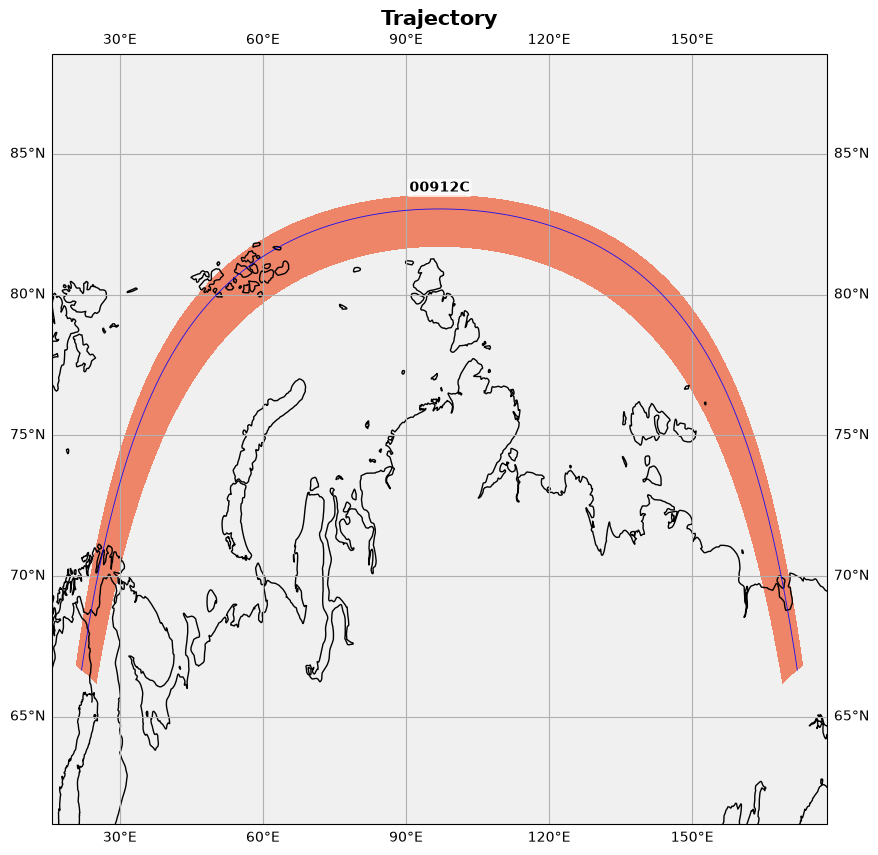

In [86]:
title="Trajectory"
save_fig = False
png_name="FIGS/Trajectory.png"

plot_traj_on_globe(ACMCOM, libRad, title=title, save_fig=save_fig, png_name=png_name)

### 3D Plot

In [87]:

def plot_3D(libRad, ACMCOM, ACMB3D, ial, iacr, title, h_max=15, fig_elev=40, which_buffer=2):
    fig         = plt.figure(figsize=FIGSIZE)
    ax          = fig.add_subplot(111, projection="3d", computed_zorder=False) # zorder to put surface-flux below others
    xlabel      = "Across-Track"; xlabel_specs = r" []"
    ylabel      = "Along-Track"; ylabel_specs = r" []"
    zlabel      = "Altitude"; zlabel_specs = r" [km]"
    handles     = []
    color_iwc   = "lightskyblue"
    color_lwc   = "white" #"lightgrey" #"whitesmoke"

    # ice_cmap    = LinearSegmentedColormap.from_list("ice_pale", ["#FFFFFF", "#DCEEFF", "#8EC5E8", "#3F88C5"])
    # water_cmap  = LinearSegmentedColormap.from_list("water_ultra_white", ["#FFFFFF", "#FFFFFF", "#F3F9FF", "#E6F3FF", "#D7EBFF"])

    ice_cmap = LinearSegmentedColormap.from_list("ice_turquoise",["#F7FFFF", "#CCF7F4", "#8DE3D8", "#4CC7C3", "#1A9AA3"])

    water_cmap = LinearSegmentedColormap.from_list("water_blue", ["#F8FBFF", "#DDEBFF", "#B7D2FF", "#7EA7FF", "#2D5BDB"])
  

    WANT_STATION_DOT    = True
    WANT_NADIR_LINE     = True
    WANT_SUN_DIRECTION  = True
    WANT_COMPASS        = True

    if 'eup' in libRad.fn:   cblabel = r"$F_{\mathrm{TOA}}^{\uparrow}$ [W/m$^2$]"
    else:                    cblabel = r"$F_{\mathrm{TOA}}^{\downarrow}$ [W/m$^2$]"

                                            

    print(libRad.fn, libRad.Name)





    # Construct 3D cloud domain using the SCA
    ########################################################################################
    Nx, Ny, iacrosses, ialongs = Calc3DBufferSize(ACMB3D, ial, iacr, BMAFLX, which_buffer)
    Nz = ACMCOM.height_layer.shape[0]
    print(f"len(ialongs) = {len(ialongs)}    len(iacrosses) = {len(iacrosses)}")



    """
    ##################### TESTING #########################
    """
    # if TESTING:
    #     iacrosses_full = iacrosses.copy()          # full buffer before truncating
    #     iacrosses = np.array([150])
    #     Nx = iacrosses.shape[0]
    #     offset = iacrosses[0] - iacrosses_full[0]  # index of 150 within the full buffer

    #     # iacrosses = np.arange(148, 164)
    #     # Nx = iacrosses.shape[0]
    """
    #######################################################
    """



    # Create grid for plotting
    #############################################################################################
    # Find index for surface index
    h = np.asarray(ACMCOM.height_layer[:, ACMB3D.index_construction[iacr, ial]][::-1])
    p = np.asarray(ACMCOM.pressure_layer_mean[:, ACMB3D.index_construction[iacr, ial]][::-1])
    valid = (h > 0) & (p < 1e10)
    if not valid.any():
        raise ValueError("No valid surface layer found")
    surface_index = np.flatnonzero(valid)[np.argmin(h[valid])]
    print(f"Surface: layer={surface_index} height={h[surface_index] / 1000:.3f} km (pressure={p[surface_index]:.0f})")

    # make edges-array -> ialongs = [10,11,12] -> edges = [10,11,12,13]
    step_x =  iacrosses[1] - iacrosses[0]   # = 1 pixel
    step_y =  ialongs[1]   - ialongs[0]     # = 1 pixel

    x_edges = np.r_[iacrosses, iacrosses[-1] + step_x] - step_x/2
    y_edges = np.r_[ialongs  , ialongs[-1]   + step_y] - step_y/2
    z_edges = np.arange(Nz + 1, dtype=float)

    X, Y = np.meshgrid(x_edges, y_edges, indexing="ij")
    Z = np.full(X.shape, surface_index, dtype=float)

    Xvoxel, Yvoxel, Zvoxel = np.meshgrid(
        x_edges,
        y_edges,
        z_edges,
        indexing="ij",
    )






  
    # Make cloud-arrays 
    ##############################################################################################
    iwc_3d = np.zeros((Nz, Nx, Ny))
    lwc_3d = np.zeros((Nz, Nx, Ny))
    height_3d = np.full((Nz, Nx, Ny), np.nan)
    cloud_mask_3d = np.zeros((Nz, Nx, Ny), dtype=bool)


    for ix, iac_ in enumerate(iacrosses):
        for iy, ial_ in enumerate(ialongs):
            # Nadir profile assigned by the SCA construction
            irec = ACMB3D.index_construction[iac_, ial_]
            for iz in range(Nz):
                h = ACMCOM.height_layer[iz, irec]
                p = ACMCOM.pressure_layer_mean[iz, irec]
                ic = ACMCOM.ice_water_content[iz, irec]
                lc = ACMCOM.liquid_water_content[iz, irec]

                valid_layer = (h > 0 and p < 1e10 and np.isfinite(h) and np.isfinite(p))
                if not valid_layer:
                    continue
                height_3d[iz, ix, iy] = h / 1000.0 # km
                if np.isfinite(ic) and ic > 0:
                    iwc_3d[iz, ix, iy] = ic
                if np.isfinite(lc) and lc > 0:
                    lwc_3d[iz, ix, iy] = lc
                cloud_mask_3d[iz, ix, iy] = (iwc_3d[iz, ix, iy] > 0 or lwc_3d[iz, ix, iy] > 0)

    # Identify clouds  (boolian mask)
    ice_cloud   = iwc_3d > 0
    water_cloud = lwc_3d > 0

    # Replace clear-sky values with NaN
    iwc_3d[~ice_cloud]      = np.nan
    lwc_3d[~water_cloud]    = np.nan

    # Convert (height, across, along) to (across, along, height)
    iwc_3d      = iwc_3d.transpose(1, 2, 0)
    lwc_3d      = lwc_3d.transpose(1, 2, 0)
    height_3d   = height_3d.transpose(1, 2, 0)
    ice_cloud   = ice_cloud.transpose(1, 2, 0)
    water_cloud = water_cloud.transpose(1, 2, 0)

    # Flip vertical axis
    iwc_3d = iwc_3d[..., ::-1]
    lwc_3d = lwc_3d[..., ::-1]
    height_3d = height_3d[..., ::-1]
    ice_cloud = ice_cloud[..., ::-1]
    water_cloud = water_cloud[..., ::-1]

    # height constraint
    height_constraint = (height_3d > 0) & (height_3d < h_max)  # km
    ice_plot = ice_cloud & height_constraint
    water_plot = water_cloud & height_constraint




    # Plot Clouds
    #########################################################################################
    #### Scale IWC and LWC
    # Log-scale only valid IWC values
    iwc_log = np.full_like(iwc_3d, np.nan)
    lwc_log = np.full_like(lwc_3d, np.nan)

    valid_lwc = np.isfinite(lwc_3d)
    valid_iwc = np.isfinite(iwc_3d)
    

    WANT_TO_PLOT_LOGARITMIC = True
    if WANT_TO_PLOT_LOGARITMIC:
        lwc_log[valid_lwc] = np.log10(lwc_3d[valid_lwc])
        iwc_log[valid_iwc] = np.log10(iwc_3d[valid_iwc])
    else:
        lwc_log[valid_lwc] = (lwc_3d[valid_lwc])
        iwc_log[valid_iwc] = (iwc_3d[valid_iwc])

    # Apply height restriction
    iwc_log[~height_constraint] = np.nan
    lwc_log[~height_constraint] = np.nan

    IWC_min = 1e-7 # kg/m^3
    IWC_max = 1e4 # kg/m^3
    LWC_min = 1e-7 # kg/m^3
    LWC_max = 1e4 # kg/m^3
    
    # Occupancy: every non-NaN logged value is plotted
    iwc_plot = np.isfinite(iwc_log) & (iwc_log >= np.log10(IWC_min)) & (iwc_log <= np.log10(IWC_max))
    lwc_plot = np.isfinite(lwc_log) & (lwc_log >= np.log10(LWC_min)) & (lwc_log <= np.log10(LWC_max))

    norm_iwc = plt.Normalize(vmin=np.log10(IWC_min), vmax=np.log10(IWC_max), clip=True)
    norm_lwc = plt.Normalize(vmin=np.log10(LWC_min), vmax=np.log10(LWC_max), clip=True)
    # maps log10(IWC) and log10(LWC) values to the [0, 1] range for colormap

    ice_colors              = ice_cmap(norm_iwc(iwc_log))
    liquid_colors           = water_cmap(norm_lwc(lwc_log))
    max_opacity             = 0.5 if WANT_EUP else 0.2
    liquid_colors[..., 3]   = np.where(lwc_plot, 0.00001 + max_opacity * norm_lwc(lwc_log), 0.0) 
    ice_colors[..., 3]      = np.where(iwc_plot, 0.00001 + max_opacity * norm_iwc(iwc_log), 0.0)
                                                # opacity in [0.001, 0.501]


                        
    WANT_CLOUD_FROM_tmpFILES = False
    if WANT_CLOUD_FROM_tmpFILES:
        # construct liquid cloud for plotting
        # tmpFILE = "tmpTESTING_v1_3155wc3D.dat" if TEST_ARVE_CODE_v1 else "tmpTESTING_v2_3155wc3D.dat" if TEST_MY_NEW_CODE_v2 else "tmpTESTING_v3_1700wc3D.dat"
        test_name = Product.split("_solar_", 1)[1].split("_Filefjell_SUR.nc", 1)[0]
        tmpFILE = f"tmp{test_name}_{ial}wc3D.dat"
        with open("tmpRTIO/" + tmpFILE, "r") as f:
            next(f)  # Skip first header line
            next(f)  # Skip height line

            lwc_plot = np.full((Nx, Ny, Nz), np.nan)


            for line in f:
                ix, iy, iz, wc, _ = line.split()
                ix = int(ix) - 1
                iy = int(iy) - 1
                iz = int(iz) - 1

                if float(wc) != 0.0:
                    lwc_plot[ix, iy, iz] = float(wc)

            # True only where cloud values exist
            lwc_mask = np.isfinite(lwc_plot) & (lwc_plot > 0)

            ax.voxels(
                Xvoxel, Yvoxel, Zvoxel,
                lwc_mask,
                facecolors="#A2CDF7",
                alpha=0.7,
                edgecolor=None,
                zorder=3
            )
            handles.append(Patch(facecolor="#A2CDF7", edgecolor="none", label="Water cloud"))

    

    else:
        # Ice clouds
        ax.voxels(
            Xvoxel, Yvoxel, Zvoxel,
            # ice_plot,
            iwc_plot,
            facecolors=ice_colors, #color_iwc,
            edgecolor=None,
            # alpha=0.1,
            shade=False,
            zorder=3
        )
        handles.append(Patch(facecolor="#BFDFFF", edgecolor="none", label="Ice cloud"))
        # Liquid-water clouds
        ax.voxels(
            Xvoxel, Yvoxel, Zvoxel,
            lwc_plot,
            facecolors=liquid_colors,
            edgecolor=None,
            # alpha=0.2,
            shade=False,
            zorder=3
        )
        handles.append(Patch(facecolor="#F5FAFF", edgecolor="none", label="Water cloud"))
    








    # Plot libRadtran fluxes
    #########################################################################################
    flux = libRad.solar_eup    # (along, Nx/across-track buffer, Ny/along-track buffer)

    # print("shape:", flux.shape)
    # print("finite values:", np.isfinite(flux).sum())
    # print("minimum:", np.nanmin(flux))
    # print("maximum:", np.nanmax(flux))
    # print("positive values:", np.count_nonzero(flux > 0))

    flux = flux[ial,:, :]

    """"""
    # if TESTING:
    #     flux = flux[offset:offset+Nx, :]
    """"""


    flux_min = np.nanmin(flux)
    flux_max = np.nanmax(flux)
    flux_min = 0.0 # Include 0 in colorbar
    # flux_max = 800
    # flux_min = 220
    # flux_max = 380
    norm = Normalize(vmin=flux_min, vmax=flux_max)
    facecolors = cmap(norm(flux))
        

    if WANT_EUP:
        # Plot at TOA
        surface_index = Nz-1
        Z = np.full(X.shape, surface_index, dtype=float)

        
    surface = ax.plot_surface(
        X,Y,Z,
        facecolors=facecolors,
        # edgecolors="none",
        antialiased=False,
        linewidth=0,
        shade=False,
        zorder=10 if WANT_EUP else 1
    )

    # Colorbar with actual flux values
    mappable = ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array(flux)
    colorbar = fig.colorbar(
        mappable,
        ax=ax,
        shrink=0.4,      # shorter colorbar
        fraction=0.08,   # thinner colorbar
        # pad=0.02,         # closer to plot
        aspect=15,        # larger = thinner,
    )
    # colorbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    colorbar.set_label(cblabel, fontsize=INFOSIZE)
    



    # Plot station location
    #########################################################################################
    if WANT_STATION_DOT:
        station_handle = ax.scatter(
                xs=iacr, ys=ial, zs=surface_index,
                c='red', 
                s=10,
                marker='o', 
                label=f"{station} GB-station\n({lat_}, {lon_})", 
                depthshade=False,
                zorder=2
                )
        handles.append(station_handle)

    # Plot sattelite nadir
    #########################################################################################
    if WANT_NADIR_LINE:
        nadir_iacross = 150
        nadir_y = np.linspace(ialongs.min(), ialongs.max(), 200)
        nadir_z = np.full_like(nadir_y, surface_index)
        nadir_x = np.full_like(nadir_y, nadir_iacross)
        nadir_handle, = ax.plot(
            nadir_x,
            nadir_y,
            nadir_z,
            color="red",
            linewidth=1,
            label="Satellite nadir",
        )
        handles.append(nadir_handle)


    # Plot SZA 
    ####################################################################################################
    sza_deg, phi0_deg = get_solar_geometry(ial)
    print(f"sza = {sza_deg:.0f}°; phi0 = {phi0_deg:.0f}° (rel to north, Clockwise)")

    # phi0_deg += 180 # Convert from clockwice from north (ECA convention) -> from south (libRad convention)
    if phi0_deg>=360: phi0_deg=phi0_deg-360
    # 3D wc and ic files are aligned parallel to the meridians, the EartCARE swath is not.
    # To correct for this perform a solar azimuth angle shift
    p0 = (ACMB3D.longitude[iacrosses[0],  ialongs[0]],   ACMB3D.latitude[iacrosses[0],  ialongs[0]])
    p1 = (ACMB3D.longitude[iacrosses[0],  ialongs[-1]],  ACMB3D.latitude[iacrosses[0],  ialongs[-1]])

    # Satelite trajectory ANGLE
    dlon = p1[0] - p0[0]
    dlat = p1[1] - p0[1]
    angle = np.degrees(np.arctan2(dlon, dlat)) % 360
    print(f"Satellite Trajectory Angle = {angle:.0f}°")
    # Get angle of satellite trajectory for plotting on North-East-South-West align plot

    # Add info to plot
    ax.text2D(
        0,0,
        f"SZA = {sza_deg:.1f}°        "+ r"$\phi_0$"+ f" = {phi0_deg:.1f}°",
        transform=ax.transAxes,
        fontsize=INFOSIZE*.8,
        verticalalignment="bottom",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="none",
            alpha=0.8),
    )


    # Add Sun Direction Arrow
    if WANT_SUN_DIRECTION:
        color = "red"
        sun = ax.inset_axes([0.9, 0.8, .1, .1])
        sun.axis("off")

        phi = np.deg2rad(phi0_deg)
        L = 3
        dx, dy = -np.sin(phi), -np.cos(phi)
        dx, dy = dx*L, dy*L

        sun.annotate("", xy=(dx,dy), xytext=(0,0), arrowprops=dict(arrowstyle="->", lw=2, color=color))
        sun.text(dx+.2, dy+.2, r"$\phi_0$ (Sun Azimuth)", ha="left", va="center", color=color)
        sun.set(xlim=(-L,L), ylim=(-L,L), aspect="equal")




    # Add compass
    ###########################################################################################################################
    if WANT_COMPASS:
        # compass = fig.add_axes([0.87, 0.87, 0.05, 0.05])
        compass = ax.inset_axes([.9, 0.8, 0.1, 0.1])
        compass.axis("off")
        for label, (x, y) in {"N":(0,1), "S":(0,-1), "W":(-1,0), "E":(1,0)}.items():
            compass.annotate("", xy=(x, y), xytext=(0, 0),
                            arrowprops=dict(arrowstyle="->", lw=1))
            compass.text(1.15*x, 1.15*y, label,
                        ha="center", va="center", fontsize=7)
        compass.set(xlim=(-1.4, 1.4), ylim=(-1.4, 1.4), aspect="equal")






    # Plot Settings 
    ####################################################################################################
    ax.set_title(title, fontsize=FONTSIZE)
    ax.set_xlabel(xlabel+xlabel_specs, fontsize=INFOSIZE)
    ax.set_ylabel(ylabel+ylabel_specs, fontsize=INFOSIZE, labelpad=15)
    ax.set_zlabel(zlabel+zlabel_specs, fontsize=INFOSIZE, labelpad=0)

    # Make correct z-axis numbers (not idx, but km)
    height_km = (np.asarray(ACMCOM.height_layer[:, ACMB3D.index_construction[iacr, ial]]) / 1000.0)[::-1]  # reverse because you flipped the plotted arrays
    # Keep only vertical layers up to h_max
    if WANT_EUP:
        below_h_max = (height_km >= height_km[0]) & (height_km <= h_max)
    else:
        below_h_max = (height_km >= height_km[surface_index]) & (height_km <= h_max)
    valid_indices = np.flatnonzero(below_h_max)

    z_min = valid_indices[0]
    z_max = valid_indices[-1]
    tick_indices = np.linspace(z_min, z_max, 5, dtype=int)

    ax.set_zlim(z_min, z_max)
    ax.set_zticks(tick_indices)
    ax.set_zticklabels([f"{height_km[i]:.1f}" for i in tick_indices])

    # ax.tick_params(axis="both", labelsize=INFOSIZE*.8) # number size on axis
    ax.tick_params(axis="x", labelsize=INFOSIZE * 0.7, pad=5)
    ax.tick_params(axis="y", labelsize=INFOSIZE * 0.7, pad=10)
    ax.tick_params(axis="z", labelsize=INFOSIZE * 0.7, pad=0)

    x_min = min(float(np.min(X)), 149.0)
    x_max = max(float(np.max(X)), 151.0)
    ax.set_xlim(x_min, x_max) 
    # ax.set_xlim(x_edges.min(), x_edges.max())
    ax.set_ylim(y_edges.min(), y_edges.max())
    
    x_len = abs(x_edges[-1] - x_edges[0])
    y_len = abs(y_edges[-1] - y_edges[0])
    z_len = max(1.0, z_max - z_min)
    z_len = min(x_len, y_len)  # Limit z_len to the smaller of x_len and y_len
    # ax.set_box_aspect((x_len, y_len, z_len), zoom=2)
    ax.set_box_aspect((x_len, y_len, z_len), zoom=1)


    ax.legend(handles=handles, loc="upper left", fontsize=FONTSIZE*.6)
    ax.grid(True, linestyle="--", alpha=0.4)
    # fig.tight_layout()

    
   
    phi0_shift = get_phi0_shift(ACMB3D, iacrosses, ialongs)
    print(f"phi0_shift = {phi0_shift}")

    ax.view_init(elev=fig_elev, azim=90 + 180 - phi0_shift)
    

    # # View from sun
    # ax.view_init(elev=fig_elev, azim=90 + angle-phi0_deg) # Seen from sun




    plt.show()

sza = 57.91976547241211
B:\publication_1\RESULTS\libRad_v01_montecarlo_3D_SWIA_solar_00912C_Iskoras_SUR.nc 00912C
len(ialongs) = 39    len(iacrosses) = 21
Surface: layer=10 height=0.602 km (pressure=93698)
sza = 58°; phi0 = 236° (rel to north, Clockwise)
Satellite Trajectory Angle = 229°
phi0_shift = 130.97010636654565


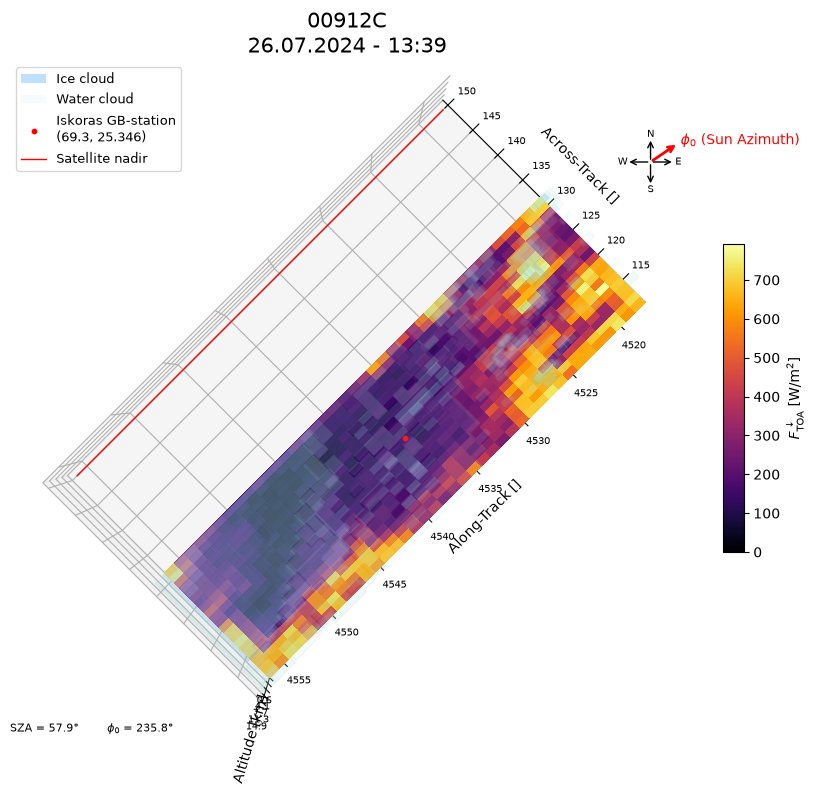

In [88]:
which_buffer = 4      # 2: 21x21, 3: 41x41, 5: SUN_BUFFER
if TESTING:
    iacr = 150
    ial = 1600

sza_deg, phi0_deg = get_solar_geometry(ial)
print(f"sza = {sza_deg}")

title       = f'{libRad.Name}\n{date} - {time}'
pngfile     = 'FIGS/3D_RT.png'
h_max       = 15  #1.3 #15 #km
fig_elev    = 90-sza_deg
# fig_elev    = 2
fig_elev    = 90



if WANT_EUP: 
    # Plot at TOA
    fig_elev = 20
    h_max    = 90

plot_3D(libRad, ACMCOM, ACMB3D, ial, iacr, title, h_max, fig_elev, which_buffer)




